In [7]:
import pandas as pd
import numpy as np

# Plotting - to make pretty graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning stuff
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# To ignore annoying warning messages
import warnings
warnings.filterwarnings('ignore')

# Make the plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("pastel")

# Load the Dataset

In [10]:
# Read the CSV file
df = pd.read_csv('Multispecies Diagnostic Records.csv')

# Let's see what we have
print("Dataset Size:", df.shape)
print(f"   → {df.shape[0]} animals, {df.shape[1]} columns\n")

print("First 5 rows of data:")
df.head()

Dataset Size: (14976, 24)
   → 14976 animals, 24 columns

First 5 rows of data:


,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Water_Intake,Daily_Steps,Disease_Prediction
0,Lion,Exotic,23,Female,234.6 kg,Lethargy,Coughing,Appetite Loss,Dehydration,10 days,...,Yes,No,No,No,Yes,41.9°C,89,5.8 L,3906,Bacterial Pneumonia
1,Lion,Exotic,5,Male,122.6 kg,Appetite Loss,Skin Lesions,Weakness,Lethargy,4 days,...,No,No,Yes,No,Yes,40.2°C,85,4.2 L,507,Heat Stress
2,Lion,Exotic,3,Female,161.5 kg,Appetite Loss,Lethargy,Labored Breathing,Dehydration,2 days,...,Yes,No,No,Yes,No,41.0°C,71,3.3 L,297,Heat Stress
3,Lion,Exotic,7,Female,169.4 kg,Lethargy,Coughing,Skin Lesions,Vomiting,2 weeks,...,Yes,No,Yes,Yes,No,40.0°C,77,3.9 L,447,Nutritional Deficiency
4,Lion,Exotic,6,Female,216.5 kg,Appetite Loss,Nasal Discharge,Fever,Labored Breathing,3 weeks,...,Yes,No,No,Yes,No,41.0°C,54,1.6 L,3072,Heat Stress


In [14]:
# Check what types of animals we have
print(" Animal Types in our Zoo:")
print(df['Animal_Type'].unique())
print(f"\nTotal different species: {df['Animal_Type'].nunique()}")

# Look at all the diseases we need to predict
print(" Diseases we're trying to predict:")
disease_counts = df['Disease_Prediction'].value_counts()
for disease, count in disease_counts.items():
    print(f"   {disease}: {count} cases")

# Quick check for missing values
print("Missing values in each column:")
missing = df.isnull().sum()
print(missing[missing > 0])  # Only show columns with missing values

 Animal Types in our Zoo:
['Lion' 'Tiger' 'Elephant' 'Crocodile' 'Chicken' 'Giraffe' 'Kangaroo'
 'Zebra' 'Panda' 'Penguin' 'Gorilla' 'Wolf' 'Cheetah' 'Flamingo' 'Lemur'
 'Sloth' 'Polar Bear' 'Red Panda' 'Meerkat' 'Hippopotamus' 'Rhinoceros'
 'Chimpanzee' 'Orangutan' 'Koala' 'Snow Leopard' 'Komodo Dragon' 'Camel'
 'Ostrich' 'Macaw' 'Sea Lion' 'Red Fox' 'Bison']

Total different species: 32
 Diseases we're trying to predict:
   Healthy: 5981 cases
   Heat Stress: 1539 cases
   Parasitic Gastritis: 1531 cases
   Viral Infection: 1503 cases
   Bacterial Pneumonia: 1492 cases
   Nutritional Deficiency: 1466 cases
   Fungal Dermatitis: 1464 cases
Missing values in each column:
Symptom_1    5981
Symptom_2    5981
Symptom_3    5981
Symptom_4    5981
Duration     5981
dtype: int64


# Clean the Data

In [17]:
#    Replace "None" with actual NaN (empty) values
symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4']
for col in symptom_cols:
    df[col] = df[col].replace('None', np.nan)

print(" Fixed 'None' values in symptom columns")

#    It has values like "234.6 kg" - we just want the number
df['Weight_kg'] = df['Weight'].str.extract(r'(\d+\.?\d*)').astype(float)
print("Extracted numeric weight values")

# Let's check a few examples
print("\nExamples of cleaned weight:")
print(df[['Weight', 'Weight_kg']].head())

#    Same thing - extract the number
df['Body_Temperature_C'] = df['Body_Temperature'].str.extract(r'(\d+\.?\d*)').astype(float)
print("Extracted numeric temperature values")

#  Clean Water Intake
df['Water_Intake_L'] = df['Water_Intake'].str.extract(r'(\d+\.?\d*)').astype(float)
print("Extracted numeric water intake values")

#    This makes it easier for the ML algorithms
binary_cols = ['Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 
               'Labored_Breathing', 'Lameness', 'Skin_Lesions', 
               'Nasal_Discharge', 'Eye_Discharge']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(" Converted Yes/No to 1/0")
print("\nExample (Appetite_Loss):")
print(df['Appetite_Loss'].value_counts())

#    Duration has values like "10 days", "2 weeks", etc.
def convert_duration(duration):
    if pd.isna(duration) or duration == 'None':
        return 0
    duration = str(duration).lower()
    if 'day' in duration:
        return float(duration.split()[0])
    elif 'week' in duration:
        return float(duration.split()[0]) * 7
    elif 'month' in duration:
        return 30  # approximate
    else:
        return 0

df['Duration_Days'] = df['Duration'].apply(convert_duration)
print(" Converted duration to days")

# Check the conversion
print("\nExamples of converted duration:")
print(df[['Duration', 'Duration_Days']].head(10))

#  Drop the original messy columns
df = df.drop(columns=['Weight', 'Body_Temperature', 'Water_Intake', 'Duration'])
print("Dropped original text columns")
print(f"New shape: {df.shape}")

#    Use median for numbers, and "Unknown" for categories
numeric_cols = ['Age', 'Weight_kg', 'Heart_Rate', 'Daily_Steps', 
                'Body_Temperature_C', 'Water_Intake_L', 'Duration_Days']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df['Gender'] = df['Gender'].fillna('Unknown')
for col in symptom_cols:
    df[col] = df[col].fillna('None')

print(" Filled all missing values")
print("\nMissing values now:", df.isnull().sum().sum())

 Fixed 'None' values in symptom columns
Extracted numeric weight values

Examples of cleaned weight:
     Weight  Weight_kg
0  234.6 kg      234.6
1  122.6 kg      122.6
2  161.5 kg      161.5
3  169.4 kg      169.4
4  216.5 kg      216.5
Extracted numeric temperature values
Extracted numeric water intake values
 Converted Yes/No to 1/0

Example (Appetite_Loss):
Appetite_Loss
0    7900
1    7076
Name: count, dtype: int64
 Converted duration to days

Examples of converted duration:
  Duration  Duration_Days
0  10 days           10.0
1   4 days            4.0
2   2 days            2.0
3  2 weeks           14.0
4  3 weeks           21.0
5   4 days            4.0
6   2 days            2.0
7  2 weeks           14.0
8      NaN            0.0
9   2 days            2.0
Dropped original text columns
New shape: (14976, 24)
 Filled all missing values

Missing values now: 0


# Create new Features

In [22]:
# 1. Count how many symptoms each animal has
df['Num_Symptoms'] = 0
for col in symptom_cols:
    df['Num_Symptoms'] += (df[col] != 'None').astype(int)

print(" Created symptom count feature")
print(df['Num_Symptoms'].value_counts().sort_index())

# 2. Count clinical signs (appetite loss, vomiting, etc.)
clinical_cols = ['Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 
                 'Labored_Breathing', 'Lameness', 'Skin_Lesions', 
                 'Nasal_Discharge', 'Eye_Discharge']
df['Num_Clinical_Signs'] = df[clinical_cols].sum(axis=1)

print("Created clinical signs count")
print(df['Num_Clinical_Signs'].describe())

# 3. Create a simple "Health Score"
#    Less symptoms = higher score
df['Health_Score'] = 10 - df['Num_Symptoms'] - (df['Num_Clinical_Signs'] * 0.5)
df['Health_Score'] = df['Health_Score'].clip(0, 10)  # Keep between 0 and 10

print(" Created health score (0-10, higher is better)")

# 4. Detect fever based on species average temperature
#    Different animals have different normal temperatures!
species_avg_temp = df.groupby('Animal_Type')['Body_Temperature_C'].transform('mean')
df['Temp_Above_Normal'] = df['Body_Temperature_C'] - species_avg_temp
df['Has_Fever'] = (df['Temp_Above_Normal'] > 2.0).astype(int)  # More than 2°C above normal

print("Created fever indicator")
print(f"Animals with fever: {df['Has_Fever'].sum()} ({df['Has_Fever'].mean()*100:.1f}%)")

# Let's look at our new features!
print(" New features we created:")
print("   - Num_Symptoms: Total symptoms reported")
print("   - Num_Clinical_Signs: Total clinical signs observed")
print("   - Health_Score: 0-10 score (higher = healthier)")
print("   - Temp_Above_Normal: How much above species average")
print("   - Has_Fever: 1 if fever detected, 0 otherwise")

 Created symptom count feature
Num_Symptoms
0    5981
4    8995
Name: count, dtype: int64
Created clinical signs count
count    14976.000000
mean         2.764890
std          2.471246
min          0.000000
25%          0.000000
50%          3.000000
75%          5.000000
max          9.000000
Name: Num_Clinical_Signs, dtype: float64
 Created health score (0-10, higher is better)
Created fever indicator
Animals with fever: 1359 (9.1%)
 New features we created:
   - Num_Symptoms: Total symptoms reported
   - Num_Clinical_Signs: Total clinical signs observed
   - Health_Score: 0-10 score (higher = healthier)
   - Temp_Above_Normal: How much above species average
   - Has_Fever: 1 if fever detected, 0 otherwise


# Explore the Data (EDA)

In [64]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

def plot_and_save(plot_func, title, filename):
    plt.figure()
    plot_func()
    plt.title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved: {filename}")

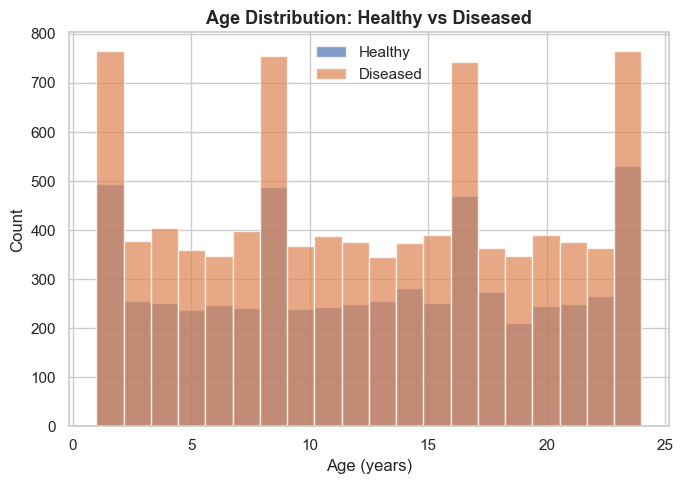

Saved: age_distribution.png


In [66]:
# Age Distribution
def plot_age_distribution():
    healthy = df[df['Disease_Prediction'] == 'Healthy']
    diseased = df[df['Disease_Prediction'] != 'Healthy']

    plt.hist(healthy['Age'], bins=20, alpha=0.7, label='Healthy')
    plt.hist(diseased['Age'], bins=20, alpha=0.7, label='Diseased')
    plt.xlabel('Age (years)')
    plt.ylabel('Count')
    plt.legend()


plot_and_save(plot_age_distribution,
              'Age Distribution: Healthy vs Diseased',
              'age_distribution.png')

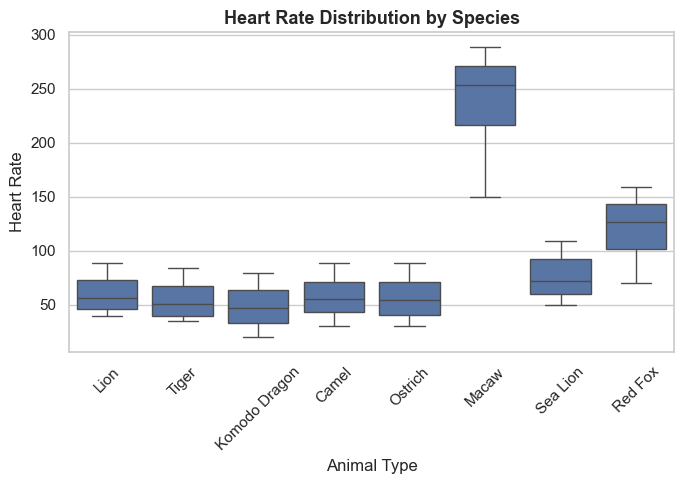

Saved: heart_rate_species.png


In [68]:
# Heart Rate by Species
def plot_heart_rate():
    top_species = df['Animal_Type'].value_counts().head(8).index
    subset = df[df['Animal_Type'].isin(top_species)]

    sns.boxplot(data=subset, x='Animal_Type', y='Heart_Rate')
    plt.xticks(rotation=45)
    plt.xlabel('Animal Type')
    plt.ylabel('Heart Rate')


plot_and_save(plot_heart_rate,
              'Heart Rate Distribution by Species',
              'heart_rate_species.png')

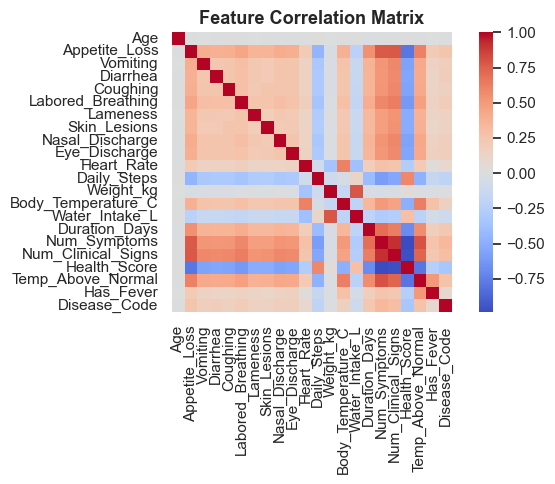

Saved: correlation_matrix.png


In [74]:
# Correlation Heatmap
def plot_correlation():
    corr = df.select_dtypes(include='number').corr()

    sns.heatmap(
        corr,
        cmap='coolwarm',
        annot=False,   
        square=True
    )


plot_and_save(plot_correlation,
              'Feature Correlation Matrix',
              'correlation_matrix.png')

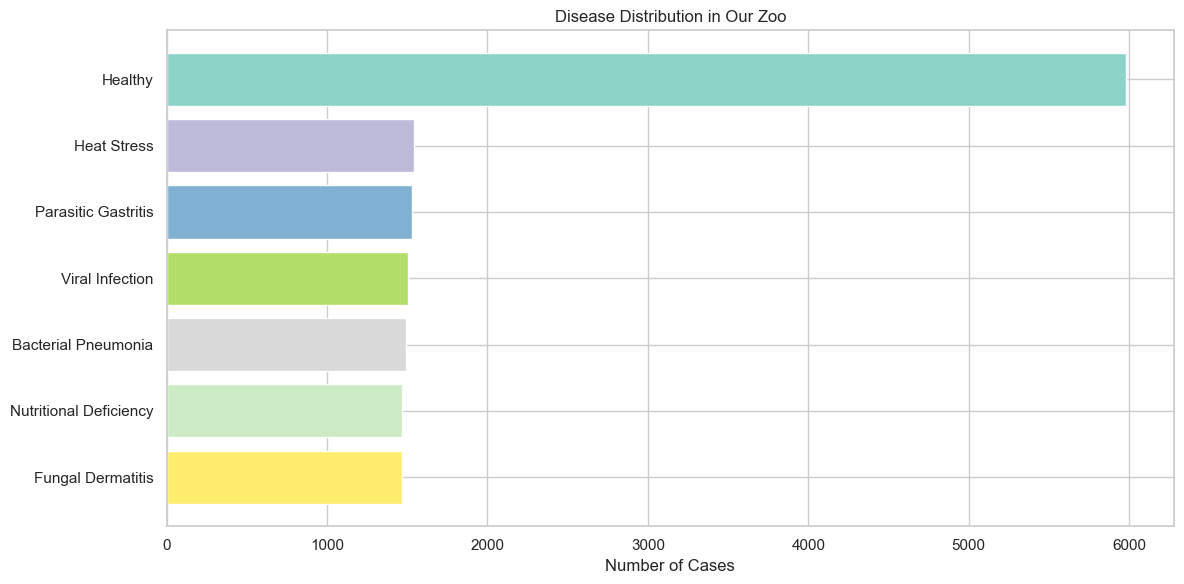

 Observation: Healthy is the most common, which makes sense!
 Bacterial Pneumonia and Viral Infection are the most common diseases.


In [76]:
# What diseases are most common?
plt.figure(figsize=(12, 6))
disease_counts = df['Disease_Prediction'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(disease_counts)))
plt.barh(range(len(disease_counts)), disease_counts.values, color=colors)
plt.yticks(range(len(disease_counts)), disease_counts.index)
plt.xlabel('Number of Cases')
plt.title('Disease Distribution in Our Zoo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(" Observation: Healthy is the most common, which makes sense!")
print(" Bacterial Pneumonia and Viral Infection are the most common diseases.")

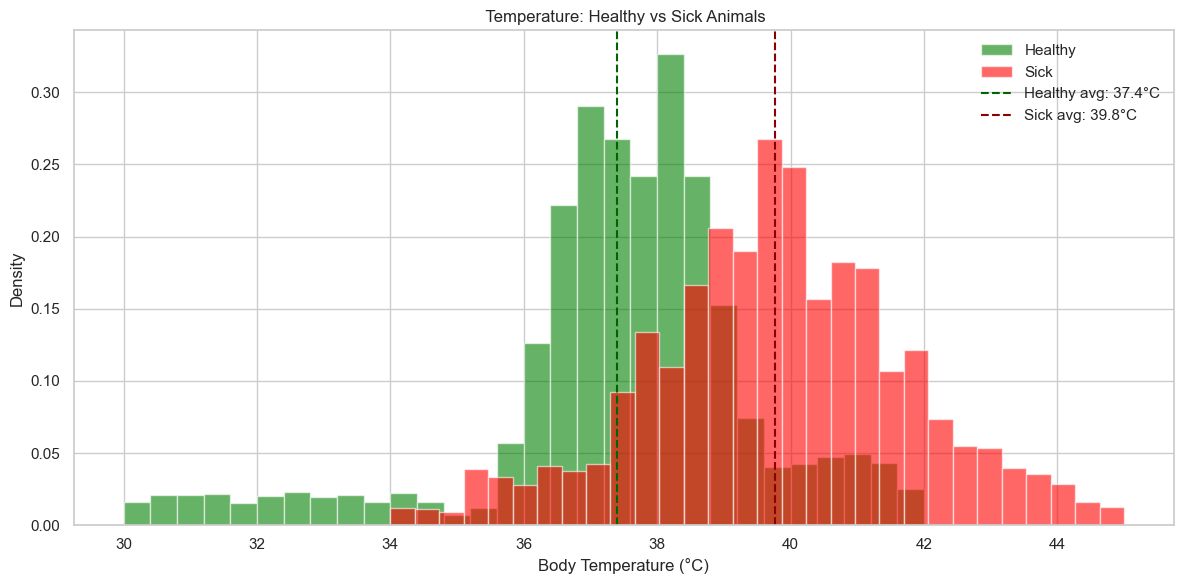

 Observation: Sick animals tend to have higher body temperature!
 Sick animals are 2.4°C hotter on average.


In [78]:
# Temperature - Healthy vs Sick
plt.figure(figsize=(12, 6))
healthy = df[df['Disease_Prediction'] == 'Healthy']['Body_Temperature_C']
sick = df[df['Disease_Prediction'] != 'Healthy']['Body_Temperature_C']

plt.hist(healthy, bins=30, alpha=0.6, label='Healthy', color='green', density=True)
plt.hist(sick, bins=30, alpha=0.6, label='Sick', color='red', density=True)
plt.axvline(healthy.mean(), color='darkgreen', linestyle='--', 
            label=f'Healthy avg: {healthy.mean():.1f}°C')
plt.axvline(sick.mean(), color='darkred', linestyle='--', 
            label=f'Sick avg: {sick.mean():.1f}°C')
plt.xlabel('Body Temperature (°C)')
plt.ylabel('Density')
plt.title(' Temperature: Healthy vs Sick Animals')
plt.legend()
plt.tight_layout()
plt.show()

print(" Observation: Sick animals tend to have higher body temperature!")
print(f" Sick animals are {sick.mean() - healthy.mean():.1f}°C hotter on average.")

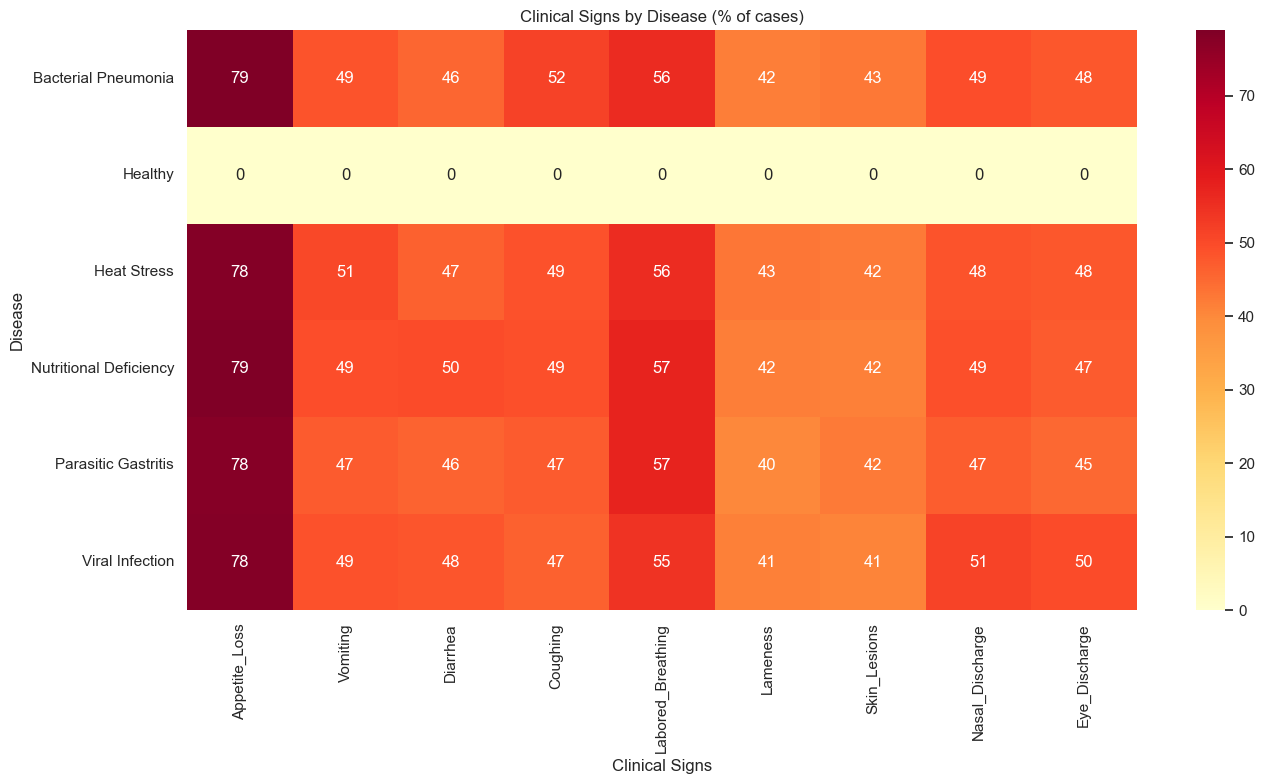

Observation: Different diseases have different symptom patterns!
For example, Bacterial Pneumonia has high coughing and labored breathing.


In [79]:
# Which symptoms appear most with each disease?
plt.figure(figsize=(14, 8))
# Get average of each clinical sign for top diseases
top_diseases = disease_counts.head(6).index
disease_symptoms = df[df['Disease_Prediction'].isin(top_diseases)].groupby('Disease_Prediction')[clinical_cols].mean() * 100

sns.heatmap(disease_symptoms, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Clinical Signs by Disease (% of cases)')
plt.xlabel('Clinical Signs')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()
print("Observation: Different diseases have different symptom patterns!")
print("For example, Bacterial Pneumonia has high coughing and labored breathing.")

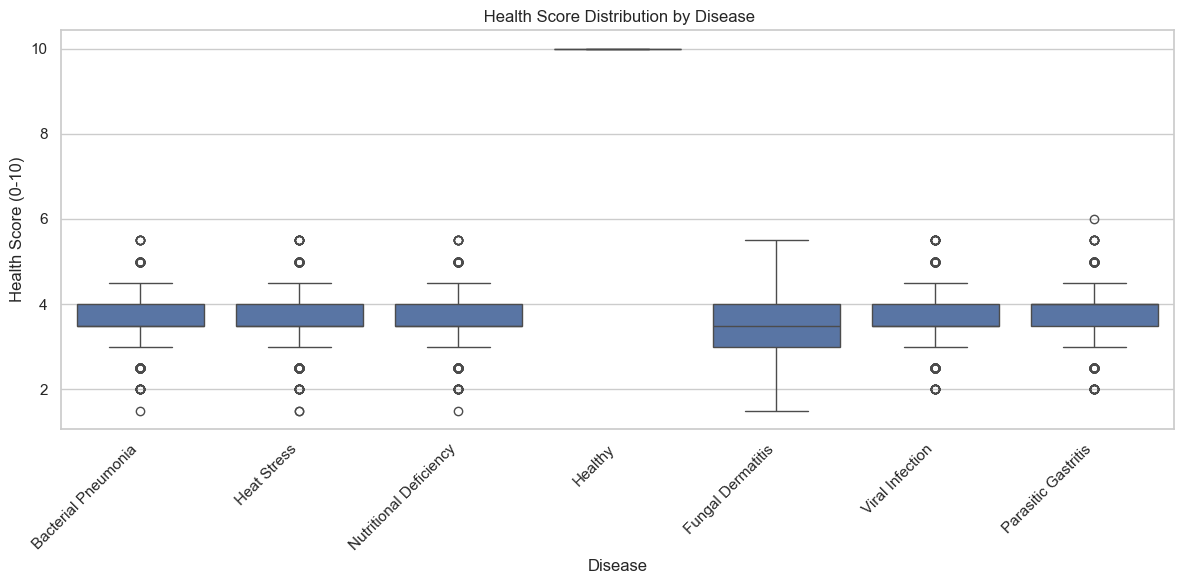

 Observation: Our Health Score feature separates healthy from sick animals well!
 Healthy animals have the highest scores, as expected.


In [81]:
# Health Score by Disease
plt.figure(figsize=(12, 6))
top_diseases = disease_counts.head(8).index
plot_data = df[df['Disease_Prediction'].isin(top_diseases)]

sns.boxplot(data=plot_data, x='Disease_Prediction', y='Health_Score')
plt.xticks(rotation=45, ha='right')
plt.title(' Health Score Distribution by Disease')
plt.xlabel('Disease')
plt.ylabel('Health Score (0-10)')
plt.tight_layout()
plt.show()

print(" Observation: Our Health Score feature separates healthy from sick animals well!")
print(" Healthy animals have the highest scores, as expected.")

# Prepare data for Machine Learning

In [40]:
# Convert disease names to numbers (0, 1, 2, ...)
le = LabelEncoder()
df['Disease_Code'] = le.fit_transform(df['Disease_Prediction'])

# Show the mapping
print(" Disease → Number Mapping:")
for i, disease in enumerate(le.classes_):
    print(f"   {i}: {disease}")

# Select features for our model
feature_cols = ['Age', 'Weight_kg', 'Body_Temperature_C', 'Heart_Rate',
                'Water_Intake_L', 'Daily_Steps', 'Duration_Days',
                'Num_Symptoms', 'Num_Clinical_Signs', 'Health_Score',
                'Temp_Above_Normal', 'Has_Fever'] + clinical_cols

X = df[feature_cols].copy()

# Add animal type as dummy variables (one-hot encoding)
# This tells the model what kind of animal it is
animal_dummies = pd.get_dummies(df['Animal_Type'], prefix='Animal')
X = pd.concat([X, animal_dummies], axis=1)

# Target variable
y = df['Disease_Code']

print(f" Features ready!")
print(f"  X shape: {X.shape} (samples × features)")
print(f"  y shape: {y.shape}")

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} animals")
print(f"Test set: {X_test.shape[0]} animals")

# Scale the features (important for some algorithms like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled to have mean=0 and std=1")


 Disease → Number Mapping:
   0: Bacterial Pneumonia
   1: Fungal Dermatitis
   2: Healthy
   3: Heat Stress
   4: Nutritional Deficiency
   5: Parasitic Gastritis
   6: Viral Infection
 Features ready!
  X shape: (14976, 53) (samples × features)
  y shape: (14976,)
Training set: 11980 animals
Test set: 2996 animals
Features scaled to have mean=0 and std=1


# Train Machine Learning Models

In [43]:
# Dictionary to store results
results = {}

In [45]:
# Model 1: Logistic Regression 
# Simple and fast - a good baseline model.

print("Training Logistic Regression...")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_lr = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

results['Logistic Regression'] = accuracy_lr

print(f"Logistic Regression Accuracy: {accuracy_lr:.2%}")

Training Logistic Regression...
Logistic Regression Accuracy: 51.20%


 Training Random Forest...
 Random Forest Accuracy: 49.87%


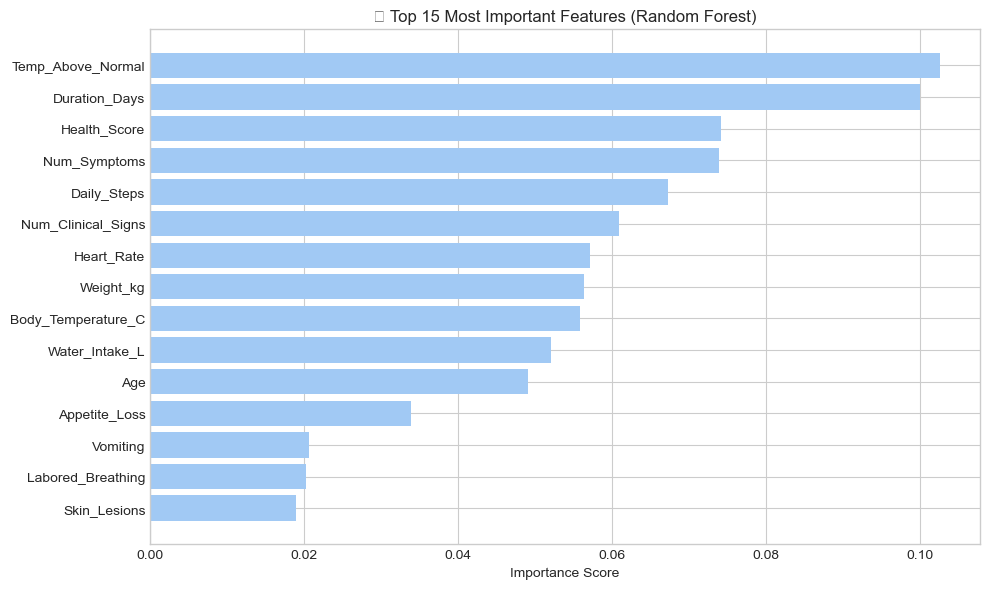

In [ ]:
# Model 2: Random Forest
# An ensemble of decision trees - usually works well with this kind of data.

print(" Training Random Forest...")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_rf = rf.predict(X_test_scaled)uu
accuracy_rf = accuracy_score(y_test, y_pred_rf)           
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    nn nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn n nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn                         n                                                                                            m  m   mmmmmmmmmmmmmmmmmmmm                                  
results['Random Forest'] = accuracy_rf                                                                                                                                                                                                                                                                                                                                                







































print(f" Random Forest Accuracy: {accuracy_rf:.2%}")

# Let's see which features Random Forest thought were most important
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['Importance'])
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
plt.xlabel('Importance Score')
plt.title('🌲 Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
# Model 3: XGBoost
# A powerful gradient boosting algorithm - often wins competitions!

print(" Training XGBoost...")

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_xgb = xgb.predict(X_test_scaled)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

results['XGBoost'] = accuracy_xgb

print(f" XGBoost Accuracy: {accuracy_xgb:.2%}")

 Training XGBoost...
 XGBoost Accuracy: 49.77%


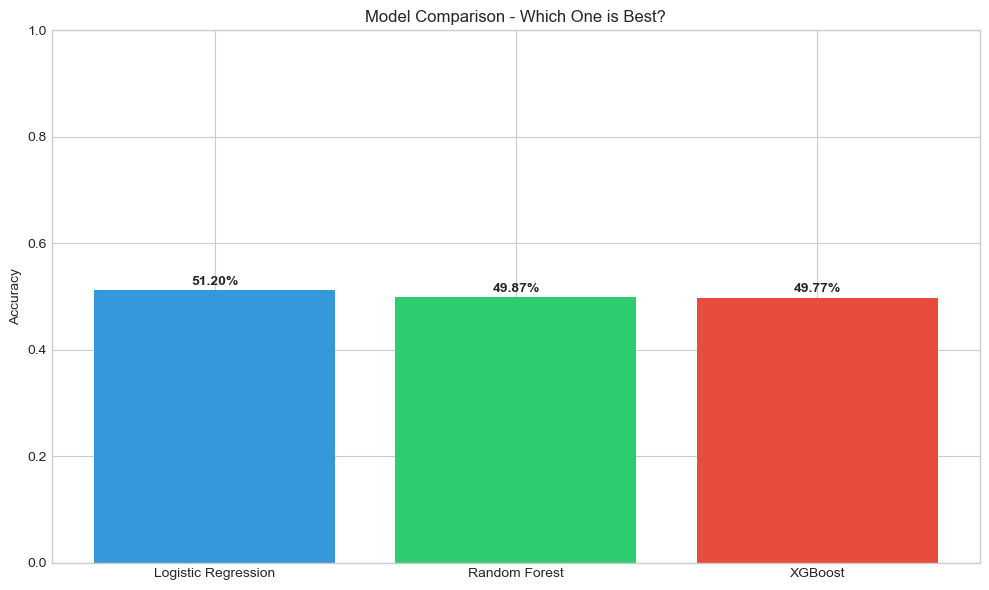


 WINNER: Logistic Regression with 51.20% accuracy!


In [51]:
# Compare Models

# Create a nice comparison bar chart
plt.figure(figsize=(10, 6))
models = list(results.keys())
accuracies = list(results.values())

bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.ylabel('Accuracy')
plt.title('Model Comparison - Which One is Best?')
plt.ylim(0, 1)

# Add accuracy labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print the winner
winner = max(results, key=results.get)
print(f"\n WINNER: {winner} with {results[winner]:.2%} accuracy!")

# Detailed Results for the Best Model

 DETAILED RESULTS: Logistic Regression

Classification Report:
                        precision    recall  f1-score   support

   Bacterial Pneumonia       0.18      0.19      0.19       298
     Fungal Dermatitis       0.18      0.16      0.17       293
               Healthy       1.00      1.00      1.00      1197
           Heat Stress       0.20      0.24      0.22       308
Nutritional Deficiency       0.17      0.11      0.13       293
   Parasitic Gastritis       0.21      0.25      0.22       306
       Viral Infection       0.17      0.16      0.16       301

              accuracy                           0.51      2996
             macro avg       0.30      0.30      0.30      2996
          weighted avg       0.51      0.51      0.51      2996



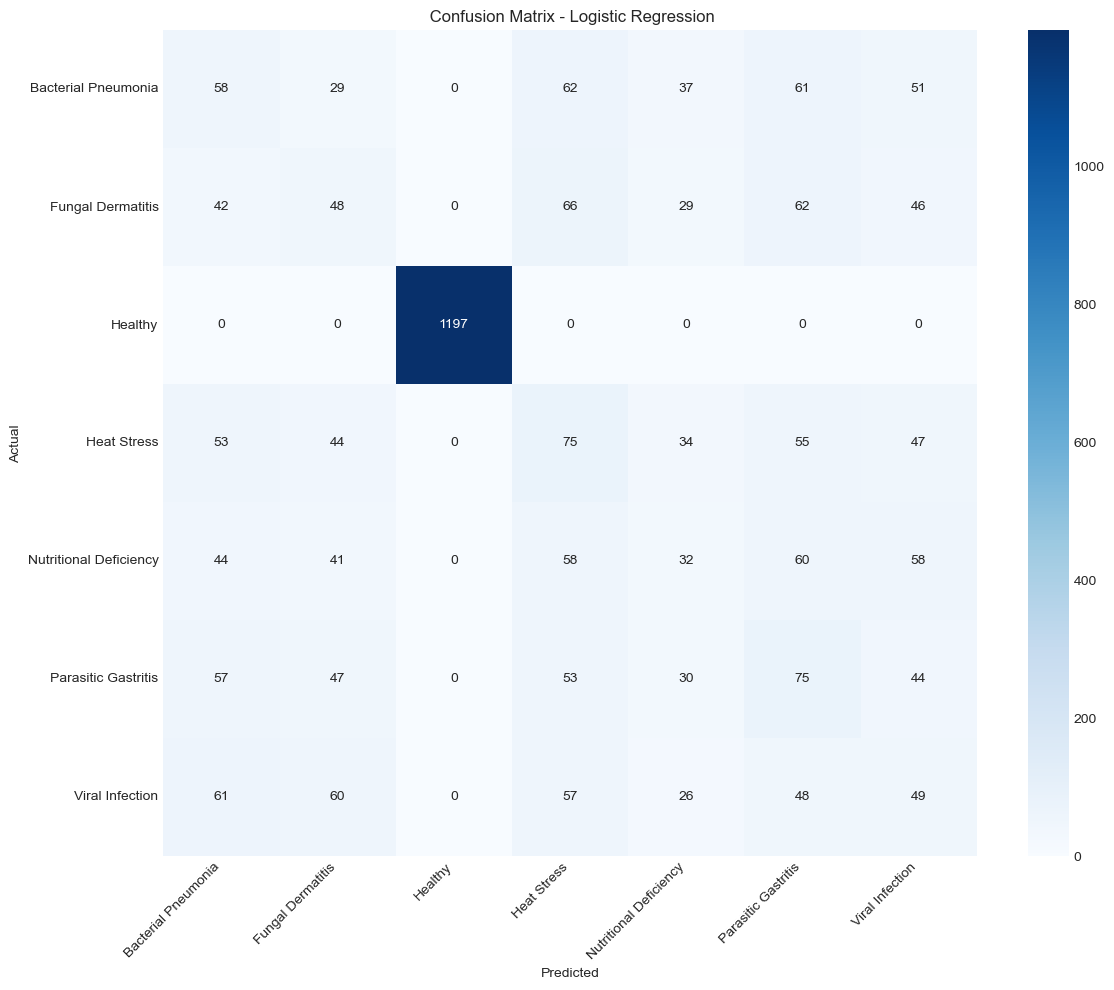

In [54]:
# Use the best model to show detailed results
if winner == 'Random Forest':
    best_model = rf
elif winner == 'XGBoost':
    best_model = xgb
else:
    best_model = lr

y_pred_best = best_model.predict(X_test_scaled)

print("=" * 60)
print(f" DETAILED RESULTS: {winner}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# %%
# Confusion Matrix - shows where the model makes mistakes
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f' Confusion Matrix - {winner}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Make a Prediction Function

In [57]:
def predict_disease(animal_type, age, weight, gender, temperature, heart_rate,
                   appetite_loss=0, vomiting=0, diarrhea=0, coughing=0,
                   labored_breathing=0, lameness=0, skin_lesions=0,
                   nasal_discharge=0, eye_discharge=0, duration_days=0):
    """
    Predict disease for a new animal based on symptoms.
    """
    # Create a dataframe with the new animal's data
    new_animal = pd.DataFrame([{
        'Age': age,
        'Weight_kg': weight,
        'Body_Temperature_C': temperature,
        'Heart_Rate': heart_rate,
        'Water_Intake_L': 5.0,  # default
        'Daily_Steps': 5000,     # default
        'Duration_Days': duration_days,
        'Num_Symptoms': sum([1 for s in [appetite_loss, vomiting, diarrhea, coughing,
                                          labored_breathing, lameness, skin_lesions,
                                          nasal_discharge, eye_discharge] if s == 1]),
        'Num_Clinical_Signs': sum([appetite_loss, vomiting, diarrhea, coughing,
                                    labored_breathing, lameness, skin_lesions,
                                    nasal_discharge, eye_discharge]),
        'Health_Score': 10 - sum([appetite_loss, vomiting, diarrhea, coughing,
                                   labored_breathing, lameness, skin_lesions,
                                   nasal_discharge, eye_discharge]),
        'Temp_Above_Normal': 0,  # will calculate below
        'Has_Fever': 0,
        'Appetite_Loss': appetite_loss,
        'Vomiting': vomiting,
        'Diarrhea': diarrhea,
        'Coughing': coughing,
        'Labored_Breathing': labored_breathing,
        'Lameness': lameness,
        'Skin_Lesions': skin_lesions,
        'Nasal_Discharge': nasal_discharge,
        'Eye_Discharge': eye_discharge
    }])
    
    # Add animal type dummy variables
    for col in animal_dummies.columns:
        new_animal[col] = 1 if col == f'Animal_{animal_type}' else 0
    
    # Make sure we have all columns in the right order
    new_animal = new_animal[X.columns]
    
    # Scale the features
    new_animal_scaled = scaler.transform(new_animal)
    
    # Make prediction
    pred_code = best_model.predict(new_animal_scaled)[0]
    pred_disease = le.inverse_transform([pred_code])[0]
    
    # Get probabilities
    if hasattr(best_model, 'predict_proba'):
        probs = best_model.predict_proba(new_animal_scaled)[0]
        top3_idx = np.argsort(probs)[-3:][::-1]
        print("\n Top 3 Predictions:")
        for idx in top3_idx:
            print(f"   {le.inverse_transform([idx])[0]}: {probs[idx]:.1%}")
    
    return pred_disease

# Test the Prediction Function

In [60]:
print(" TEST CASE 1: Sick Lion with fever and cough")
print("-" * 40)
result1 = predict_disease(
    animal_type='Lion',
    age=5,
    weight=150,
    gender='Male',
    temperature=41.5,  # Fever!
    heart_rate=95,
    coughing=1,
    labored_breathing=1,
    appetite_loss=1,
    duration_days=7
)
print(f"\n→ Predicted Disease: {result1}")

print("\n" + "=" * 60 + "\n")

print(" TEST CASE 2: Healthy Penguin")
print("-" * 40)
result2 = predict_disease(
    animal_type='Penguin',
    age=3,
    weight=25,
    gender='Female',
    temperature=38.5,  # Normal
    heart_rate=90,
    duration_days=0
)
print(f"\n→ Predicted Disease: {result2}")

 TEST CASE 1: Sick Lion with fever and cough
----------------------------------------

 Top 3 Predictions:
   Heat Stress: 19.6%
   Parasitic Gastritis: 18.6%
   Fungal Dermatitis: 17.3%

→ Predicted Disease: Heat Stress


 TEST CASE 2: Healthy Penguin
----------------------------------------

 Top 3 Predictions:
   Healthy: 99.9%
   Bacterial Pneumonia: 0.0%
   Parasitic Gastritis: 0.0%

→ Predicted Disease: Healthy


In [ ]:
import pandas as pd
import numpy as np
import random
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

df = pd.read_csv('Multispecies Diagnostic Records.csv')
feature_cols = ['Body_Temperature', 'Duration_Days', 'Appetite_Loss', 'Vomiting', 'Diarrhea',
                 'Coughing', 'Labored_Breathing', 'Lameness', 'Skin_Lesions',
                 'Nasal_Discharge', 'Eye_Discharge']

def parse_duration(dur):
    if pd.isna(dur):
        return 0
    dur_str = str(dur)
    if 'day' in dur_str:
        num = dur_str.split()[0]
        if num == 'None':
            return 0
        try:
            return int(num)
        except:
            return 5
    elif 'week' in dur_str:
        num = dur_str.split()[0]
        try:
            return int(num) * 7
        except:
            return 14
    else:
        return 0

df['Duration_Days'] = df['Duration'].apply(parse_duration)
for col in ['Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing',
            'Lameness', 'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Очищаем температуру
df['Body_Temperature'] = df['Body_Temperature'].str.replace('°C', '').astype(float)

# Убираем NaN
df_clean = df[feature_cols + ['Animal_Type', 'Age', 'Disease_Prediction']].dropna()

# Кодируем диагнозы
le = LabelEncoder()
y = le.fit_transform(df_clean['Disease_Prediction'])
X = df_clean[feature_cols]

# Обучаем Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

print("✅ Модель обучена!")
print(f" Possible diases: {list(le.classes_)}")
print("="*60)

random_idx = random.randint(0, len(df_clean) - 1)
secret_animal = df_clean.iloc[random_idx]

print("\n" + "🐾" * 15)
print("   ВЕТЕРИНАРНЫЙ ТЕСТ")
print("🐾" * 15)
print(f"\n ТЕБЕ ПОПАЛСЯ: {secret_animal['Animal_Type']}, {secret_animal['Age']} лет")
print("    YOU DON'T KNOW THE DIAGNOSES!")
print("    MAKE DIAGNOSTICS\n")
print("="*60)

print("\n Duration of a disease:")
print("   1. 1-3 дня")
print("   2. 4-7 дней")
print("   3. 8-14 дней")
print("   4. Более 14 дней")
print("   5. Не знаю / Нет данных")

dur_choice = input("\n Твой выбор (1/2/3/4/5): ")

if dur_choice == '1':
    duration = 2
    dur_desc = "1-3 дня"
elif dur_choice == '2':
    duration = 5
    dur_desc = "4-7 дней"
elif dur_choice == '3':
    duration = 10
    dur_desc = "8-14 дней"
elif dur_choice == '4':
    duration = 20
    dur_desc = "Более 14 дней"
else:
    duration = 5
    dur_desc = "Не знаю (принято за 5 дней)"

print(f"    {dur_desc}")

print("\n TEMPERATURE BODY:")
print("   1. Нормальная (36.5 - 38.5°C)")
print("   2. Повышенная (38.6 - 40.0°C)")
print("   3. Высокая (40.1 - 42.0°C)")
print("   4. Не знаю / Нет данных")

temp_choice = input("\n Твой выбор (1/2/3/4): ")

if temp_choice == '1':
    temperature = 37.5
    temp_desc = "Нормальная (37.5°C)"
elif temp_choice == '2':
    temperature = 39.5
    temp_desc = "Повышенная (39.5°C)"
elif temp_choice == '3':
    temperature = 41.0
    temp_desc = "Высокая (41.0°C)"
else:
    temperature = 38.5
    temp_desc = "Не знаю (принято за 38.5°C)"

print(f"    {temp_desc}")


print("\n📋 SYMPTOM (ANSWER: YES / NO / IDK):")

symptom_names = {
    'Appetite_Loss': '  Appetite_Loss',
    'Vomiting': ' Vomiting',
    'Diarrhea': ' Diarrhea',
    'Coughing': ' Coughing',
    'Labored_Breathing': ' Labored_Breathing',
    'Lameness': ' Lameness',
    'Skin_Lesions': ' Skin_Lesions',
    'Nasal_Discharge': ' Nasal_Discharge',
    'Eye_Discharge': '  Eye_Discharge'
}

symptom_values = {}

for symptom, display in symptom_names.items():
    print(f"\n   {display}")
    print("      1. YES")
    print("      2. NO")
    print("      3. IDK")
    
    answer = input("   YOUR CHOICE (1/2/3): ")
    
    if answer == '1':
        symptom_values[symptom] = 1
        print("      ✅ ДА")
    elif answer == '2':
        symptom_values[symptom] = 0
        print("      ❌ НЕТ")
    else:
        symptom_values[symptom] = 0.1

input_data = [[temperature, duration] + [symptom_values[s] for s in symptom_names.keys()]]
proba = rf.predict_proba(input_data)[0]
pred_idx = np.argmax(proba)
confidence = proba[pred_idx] * 100
predicted = le.classes_[pred_idx]

print("\n" + "="*60)
print("🩺 РЕЗУЛЬТАТ ДИАГНОСТИКИ 🩺")
print("="*60)

print(f"\n PREDICTION: {predicted}")
print(f" ACCURACY: {confidence:.1f}%")

print("\n OTHER POSSIBLE DIASES:")
top3_idx = np.argsort(proba)[-3:][::-1]
for i in top3_idx:
    if le.classes_[i] != predicted:
        print(f"   • {le.classes_[i]}: {proba[i]*100:.1f}%")
# TREATMENTS
treatments = {
    "Bacterial Pneumonia": " Антибиотики + покой + обильное питье",
    "Heat Stress": " Охлаждение + тень + вода + электролиты",
    "Viral Infection": " Поддерживающая терапия + изоляция",
    "Parasitic Gastritis": " Противопаразитарные + диета + пробиотики",
    "Nutritional Deficiency": " Сбалансированное питание + витамины",
    "Fungal Dermatitis": " Противогрибковое лечение + сухость",
    "Healthy": " Только плановый осмотр"
}

print(f"\n RECOMENDATION PART: {treatments.get(predicted, 'Консультация ветврача')}")
print("="*60)

✅ Модель обучена!
 Possible diases: ['Bacterial Pneumonia', 'Fungal Dermatitis', 'Healthy', 'Heat Stress', 'Nutritional Deficiency', 'Parasitic Gastritis', 'Viral Infection']

🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾
   ВЕТЕРИНАРНЫЙ ТЕСТ
🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾🐾

 ТЕБЕ ПОПАЛСЯ: Rhinoceros, 1 лет
    YOU DON'T KNOW THE DIAGNOSES!
    MAKE DIAGNOSTICS


 Duration of a disease:
   1. 1-3 дня
   2. 4-7 дней
   3. 8-14 дней
   4. Более 14 дней
   5. Не знаю / Нет данных
